# TP1 (a completer) : K-means + ACP — *Iris*

Remplacez chaque `...` et chaque `# TODO`. Le corrige (`../notebooks/TP1_kmeans_acp.ipynb`)
applique la **meme demarche sur un AUTRE dataset (Wine)** : la structure est
identique, seules les donnees et les colonnes changent : a vous d'adapter.

**Objectif.** Retrouver, par clustering, les **3 especes** de 150 fleurs d'iris
decrites par **4 mesures** (longueur/largeur des petales et des sepales), sans
utiliser l'etiquette ; puis valider et qualifier.

In [1]:
%matplotlib inline
# Cellule fournie : a executer telle quelle.
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

NAVY, ACCENT, GRAY = "#16284D", "#0EA5E9", "#5B6679"
RED = "#C0504D"
PALETTE = [ACCENT, NAVY, "#F79646", "#3FA45B", RED]
plt.rcParams.update({
    "figure.figsize": (7, 4.5), "font.size": 12,
    "axes.titlecolor": NAVY, "axes.titleweight": "bold",
    "axes.edgecolor": GRAY, "axes.spines.top": False, "axes.spines.right": False,
})
pd.set_option("display.width", 120)
print("Environnement pret.")

Environnement pret.


## Etape 0 : charger les donnees (fournie)

In [2]:
from sklearn.datasets import load_iris
ds = load_iris(as_frame=True)
X = ds.data
espece = ds.target     # 0,1,2 : garde de cote pour la validation
X.head()

,sepal length (cm),sepal width (cm),petal length (cm),petal width (cm)
0,5.1,3.5,1.4,0.2
1,4.9,3.0,1.4,0.2
2,4.7,3.2,1.3,0.2
3,4.6,3.1,1.5,0.2
4,5.0,3.6,1.4,0.2


## 1. Exploration
**Consigne.** Affichez la moyenne et l'ecart-type de chaque variable pour
constater les differences d'echelle.

In [3]:
# Statistiques descriptives : moyenne et ecart-type de chaque variable
X.describe().round(2).T[["mean", "std"]]

,mean,std
sepal length (cm),5.84,0.83
sepal width (cm),3.06,0.44
petal length (cm),3.76,1.77
petal width (cm),1.20,0.76


## 2.a Standardisation
**Consigne.** Standardisez `X` (moyenne 0, ecart-type 1) avec `StandardScaler`.

In [4]:
from sklearn.preprocessing import StandardScaler

X_std = StandardScaler().fit_transform(X)

## 2.b Choisir k
**Consigne.** Pour `k` de 2 a 8, entrainez un `KMeans` et stockez l'inertie
(`.inertia_`) et la silhouette (`silhouette_score`). Tracez les deux courbes et
lisez le `k_best` qui maximise la silhouette. **Attention** : ce `k_best` ne
coincide pas toujours avec le vrai nombre de groupes.

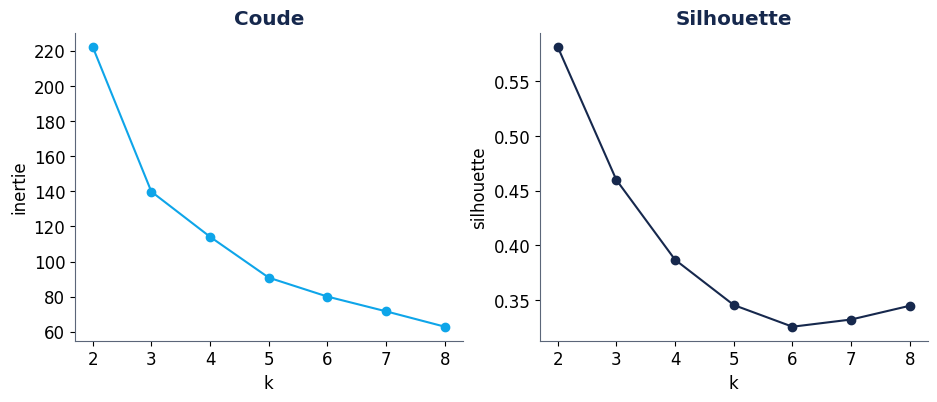

k retenu : 2


In [5]:
from sklearn.cluster import KMeans
from sklearn.metrics import silhouette_score

ks = range(2, 9)
inerties, silhouettes = [], []
for k in ks:
    km = KMeans(n_clusters=k, n_init=10, random_state=0).fit(X_std)
    inerties.append(km.inertia_)
    silhouettes.append(silhouette_score(X_std, km.labels_))

k_best = list(ks)[int(np.argmax(silhouettes))]

fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(11, 4))
ax1.plot(list(ks), inerties, "-o", color=ACCENT)
ax1.set(title="Coude", xlabel="k", ylabel="inertie")
ax2.plot(list(ks), silhouettes, "-o", color=NAVY)
ax2.set(title="Silhouette", xlabel="k", ylabel="silhouette")
plt.show()
print("k retenu :", k_best)

> **A observer.** Sur Iris, la silhouette est maximale a **k = 2**, pas 3 : une
> espece (*setosa*) se detache tres nettement, alors que les deux autres se
> **chevauchent**. Comme on **sait** qu'il y a **3 especes**, on poursuit avec
> `k = 3` pour comparer le clustering a la realite (lecon : la silhouette ne donne
> pas toujours le vrai nombre de classes).

## 3. Evaluation + validation
**Consigne.** Entrainez le modele final avec **`k = 3`**. Affichez l'inertie, la
silhouette, puis **validez** : calculez l'`adjusted_rand_score` entre `espece` et
les clusters, et affichez le `pd.crosstab`.

In [6]:
from sklearn.metrics import adjusted_rand_score

k = 3                  # on connait 3 especes (cf. note ci-dessus)
km = KMeans(n_clusters=k, n_init=10, random_state=0).fit(X_std)
labels = km.labels_
print(f"Inertie    : {km.inertia_:.1f}")
print(f"Silhouette : {silhouette_score(X_std, labels):.3f}")
print(f"Adjusted Rand Index (clusters vs especes) : {adjusted_rand_score(espece, labels):.3f}")
pd.crosstab(labels, espece, rownames=["cluster"], colnames=["espece reelle"])

Inertie    : 139.8
Silhouette : 0.460
Adjusted Rand Index (clusters vs especes) : 0.620


espece reelle,0,1,2
cluster,,,
0,0,39,14
1,50,0,0
2,0,11,36


## 4. Visualisation ACP
**Consigne.** Projetez `X_std` en 2D avec `PCA(n_components=2)`, puis tracez un
nuage de points colore par cluster (ajoutez les centres si vous le souhaitez).

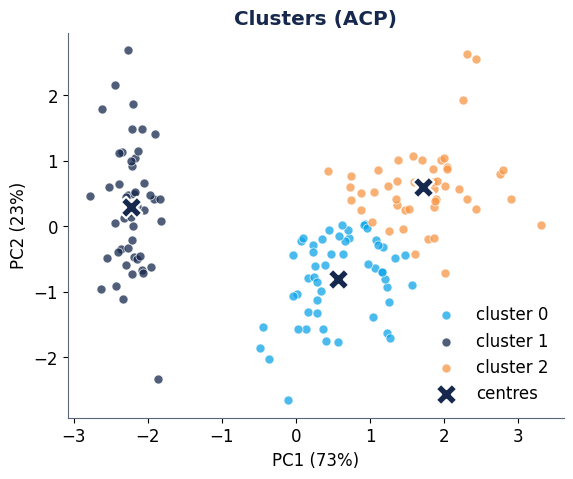

In [7]:
from sklearn.decomposition import PCA

pca = PCA(n_components=2, random_state=0)
coords = pca.fit_transform(X_std)
centres = pca.transform(km.cluster_centers_)
var = pca.explained_variance_ratio_

fig, ax = plt.subplots(figsize=(6.4, 5))
for c in sorted(np.unique(labels)):
    m = labels == c
    ax.scatter(coords[m, 0], coords[m, 1], s=42, alpha=0.75, color=PALETTE[c],
               edgecolor="white", linewidth=0.6, label=f"cluster {c}")
ax.scatter(centres[:, 0], centres[:, 1], marker="X", s=240, color=NAVY,
           edgecolor="white", linewidth=1.6, zorder=5, label="centres")
ax.set(title="Clusters (ACP)", xlabel=f"PC1 ({var[0]:.0%})", ylabel=f"PC2 ({var[1]:.0%})")
ax.legend(frameon=False)
plt.show()

## 5 & 6. Integration + qualification
**Consigne.** Ajoutez la colonne `cluster` a une copie de `X`, puis calculez le
profil moyen (`groupby`) des variables cles par cluster. Ajoutez aussi l'effectif
de chaque cluster.

In [8]:
fleurs = X.copy()
fleurs["cluster"] = labels
cles = list(X.columns)   # les 4 mesures d'iris
profil = fleurs.groupby("cluster")[cles].mean().round(2)
profil["effectif"] = fleurs.groupby("cluster").size()
profil

,sepal length (cm),sepal width (cm),petal length (cm),petal width (cm),effectif
cluster,,,,,
0,5.80,2.67,4.37,1.41,53
1,5.01,3.43,1.46,0.25,50
2,6.78,3.10,5.51,1.97,47


### 6.a Distribution par cluster : boxplots
**Consigne.** La moyenne **cache la dispersion**. Tracez un boxplot par cluster
pour les 4 mesures d'iris. Pour chaque sous-graphe, `paquets` doit etre la **liste
des valeurs de la variable, un element par cluster**. Reperez ensuite les variables
les plus **discriminantes** (boites bien separees).

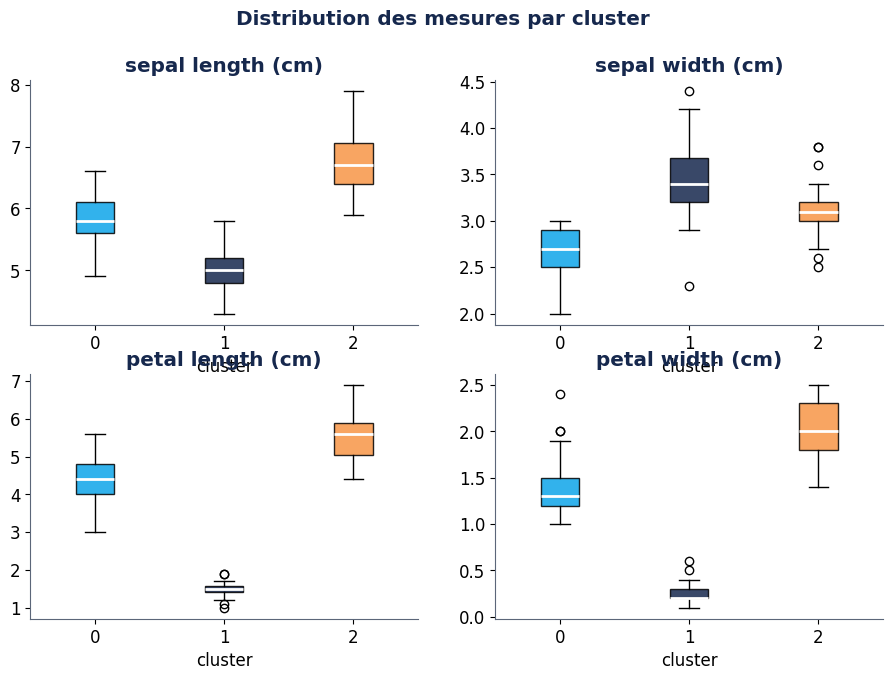

In [9]:
groupes = sorted(fleurs["cluster"].unique())
fig, axes = plt.subplots(2, 2, figsize=(11, 7))
for ax, col in zip(axes.ravel(), X.columns):
    paquets = [fleurs.loc[fleurs["cluster"] == c, col] for c in groupes]
    bp = ax.boxplot(paquets, patch_artist=True, medianprops=dict(color="white", lw=2))
    for patch, c in zip(bp["boxes"], groupes):
        patch.set(facecolor=PALETTE[c], alpha=0.85)
    ax.set_title(col); ax.set_xlabel("cluster")
    ax.set_xticks(range(1, len(groupes) + 1)); ax.set_xticklabels(groupes)
fig.suptitle("Distribution des mesures par cluster", color=NAVY, fontweight="bold")
plt.show()

### 6.b Signature complete : heatmap des moyennes standardisees
**Consigne.** Pour comparer les 4 variables d'un coup, calculez la **moyenne
standardisee** de chaque variable par cluster (sur `X_std`) et affichez-la en
heatmap. Rouge = au-dessus de la moyenne generale, bleu = en dessous. Donnez
ensuite un **nom** (un profil) a chaque cluster.

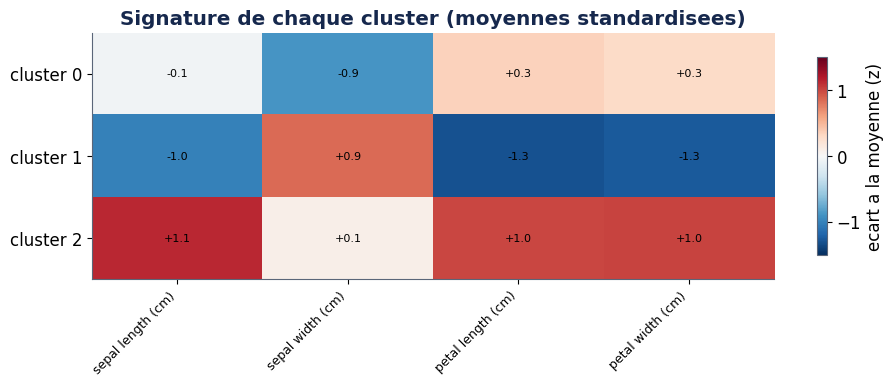

In [10]:
profil_z = pd.DataFrame(X_std, columns=X.columns)
profil_z["cluster"] = labels
moyennes_z = profil_z.groupby("cluster").mean()

fig, ax = plt.subplots(figsize=(11, 3.2))
im = ax.imshow(moyennes_z, cmap="RdBu_r", vmin=-1.5, vmax=1.5, aspect="auto")
ax.set_xticks(range(len(X.columns)))
ax.set_xticklabels(X.columns, rotation=45, ha="right", fontsize=9)
ax.set_yticks(range(len(moyennes_z)))
ax.set_yticklabels([f"cluster {c}" for c in moyennes_z.index])
for i in range(moyennes_z.shape[0]):
    for j in range(moyennes_z.shape[1]):
        ax.text(j, i, f"{moyennes_z.iloc[i, j]:+.1f}", ha="center", va="center", fontsize=8)
fig.colorbar(im, ax=ax, shrink=0.8, label="ecart a la moyenne (z)")
ax.set_title("Signature de chaque cluster (moyennes standardisees)")
plt.show()

## 7. Aller plus loin : le clustering hierarchique (CAH)

K-means n'est pas la seule methode de clustering. La **Classification Ascendante
Hierarchique (CAH)** procede autrement :

1. au depart, **chaque fleur est seule** dans son cluster ;
2. a chaque etape, on **fusionne les deux clusters les plus proches** ;
3. on continue jusqu'a n'avoir **qu'un seul cluster**.

L'historique des fusions se lit sur un **dendrogramme** : on le "coupe" a la
hauteur voulue pour obtenir k clusters. Avantage : pas besoin de fixer k a
l'avance, et la structure est visible.

**Consigne.** Tracez le dendrogramme (methode de Ward sur `X_std`), puis
recuperez 3 clusters avec `AgglomerativeClustering` et comparez-les aux clusters
K-means et aux vraies especes (ARI).

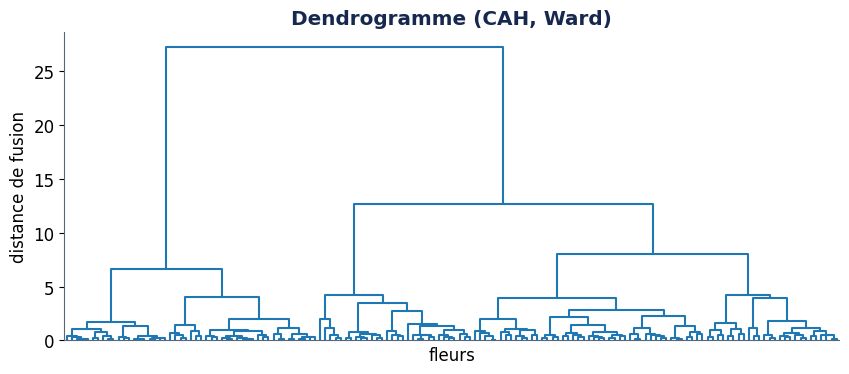

In [11]:
from scipy.cluster.hierarchy import dendrogram, linkage

# 1. Matrice de liaison (linkage) par la methode de Ward sur les donnees standardisees
Z = linkage(X_std, method="ward")

# 2. Dendrogramme
fig, ax = plt.subplots(figsize=(10, 4))
dendrogram(Z, no_labels=True, color_threshold=0, ax=ax)
ax.set(title="Dendrogramme (CAH, Ward)", xlabel="fleurs", ylabel="distance de fusion")
plt.show()

In [12]:
from sklearn.cluster import AgglomerativeClustering

# 3. Couper l'arbre pour obtenir 3 clusters
cah = AgglomerativeClustering(n_clusters=3, linkage="ward")
labels_cah = cah.fit_predict(X_std)

# 4. Comparer : CAH vs K-means (accord entre les 2 methodes), et CAH vs vraies especes
print(f"ARI CAH vs K-means : {adjusted_rand_score(labels, labels_cah):.3f}")
print(f"ARI CAH vs especes : {adjusted_rand_score(espece, labels_cah):.3f}")
pd.crosstab(labels_cah, espece, rownames=["CAH"], colnames=["espece reelle"])

ARI CAH vs K-means : 0.626
ARI CAH vs especes : 0.615


espece reelle,0,1,2
CAH,,,
0,0,23,48
1,49,0,0
2,1,27,2


## Bonus : la meme analyse sans standardisation

**Consigne (cf. "A rendre").** Refaites le clustering K-means (`k=3`) directement
sur `X` brut (sans `StandardScaler`), et comparez l'ARI obtenu a celui obtenu avec
`X_std`.

In [13]:
# Meme clustering, mais sur les donnees BRUTES (non standardisees)
km_brut = KMeans(n_clusters=3, n_init=10, random_state=0).fit(X)
labels_brut = km_brut.labels_

print(f"ARI sans standardisation : {adjusted_rand_score(espece, labels_brut):.3f}")
print(f"ARI avec standardisation  : {adjusted_rand_score(espece, labels):.3f}")
pd.crosstab(labels_brut, espece, rownames=["cluster (brut)"], colnames=["espece reelle"])

ARI sans standardisation : 0.730
ARI avec standardisation  : 0.620


espece reelle,0,1,2
cluster (brut),,,
0,0,48,14
1,50,0,0
2,0,2,36


## A rendre

**Ce que dit la silhouette sur le nombre de groupes, et pourquoi on retient `k = 3`.**
La silhouette est maximale a `k = 2` : *setosa* se detache tres nettement du reste,
tandis que *versicolor* et *virginica* se chevauchent et ne forment pas deux groupes
bien separes au sens de la silhouette. On retient neanmoins `k = 3` car on connait,
par construction du jeu de donnees, le nombre reel d'especes : l'objectif n'est pas de
deviner k mais de verifier si K-means retrouve la bonne partition quand on le lui donne.

**L'ARI obtenu et l'interpretation du tableau croise.**
Avec `k = 3` : silhouette = 0.460, ARI = 0.620. Le tableau croise montre que *setosa*
est retrouvee parfaitement (50/50, cluster 1). *Versicolor* et *virginica* se
confondent partiellement : 14 *virginica* sont classees avec le cluster majoritairement
*versicolor*, et 11 *versicolor* avec le cluster majoritairement *virginica*. C'est le
chevauchement deja visible sur le score de silhouette qui se retrouve ici.

**Les 2 variables les plus discriminantes (d'apres les boxplots).**
`petal length` et `petal width` separent tres nettement les clusters (boites quasi
disjointes). `sepal length` et surtout `sepal width` se chevauchent beaucoup plus :
seules, elles ne suffiraient pas a distinguer les especes.

**Qualification de chaque cluster (heatmap).**
- Cluster 0 : petales de longueur/largeur moyennes -> *versicolor*.
- Cluster 1 : petales tres petits (longueur et largeur nettement en dessous de la
  moyenne) -> *setosa*.
- Cluster 2 : petales (et sepales) les plus grands -> *virginica*.

**Comparaison K-means vs CAH, et lecture du dendrogramme.**
ARI(CAH, K-means) = 0.626 : les deux methodes s'accordent fortement entre elles, pas
seulement par rapport aux vraies especes. ARI(CAH, especes) = 0.615, tres proche de
celui de K-means (0.620). Le dendrogramme confirme cette lecture : une premiere
coupure tres nette (distance de fusion ~27) isole un tiers des fleurs (*setosa*), puis
le reste se scinde a une hauteur bien plus faible (~13) en deux sous-groupes proches
(*versicolor*/*virginica*) : la encore, c'est le chevauchement de ces deux especes qui
limite les deux methodes de la meme maniere.

**Bonus : sans standardisation, que devient l'ARI ?**
Contrairement a l'intuition habituelle ("il faut toujours standardiser"), l'ARI
**augmente** ici : il passe de 0.620 (avec `X_std`) a 0.730 (avec `X` brut). La raison :
sur Iris, toutes les variables sont deja sur une echelle comparable (en cm), contrairement
a Wine ou les echelles different de plusieurs ordres de grandeur (`proline` en centaines vs
`flavanoids` en unites). Ici, ne pas standardiser donne simplement plus de poids dans le
calcul des distances aux variables de plus grande variance brute, en l'occurrence `petal
length` -- qui se trouve etre justement la variable la plus discriminante. La
standardisation reste une bonne pratique par defaut (et c'est elle qui generalise le mieux
a un nouveau jeu de donnees dont on ne connait pas a l'avance les variables
discriminantes), mais ce cas montre qu'elle n'ameliore pas systematiquement le resultat.